In [7]:
import torch
from torch import nn
from d2l import torch as d2l

In [8]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [9]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, 0, 0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

In [10]:
loss = nn.CrossEntropyLoss(reduction='none')

In [11]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

epoch  1  loss 94.9330  train acc 0.683  test acc 0.812
epoch  2  loss 50.0153  train acc 0.762  test acc 0.808
epoch  3  loss 45.2043  train acc 0.771  test acc 0.834
epoch  4  loss 42.7358  train acc 0.781  test acc 0.834
epoch  5  loss 41.3653  train acc 0.785  test acc 0.824
epoch  6  loss 39.2595  train acc 0.789  test acc 0.835
epoch  7  loss 38.3766  train acc 0.790  test acc 0.821
epoch  8  loss 39.1297  train acc 0.791  test acc 0.799
epoch  9  loss 39.2273  train acc 0.792  test acc 0.839
epoch 10  loss 38.1724  train acc 0.795  test acc 0.815


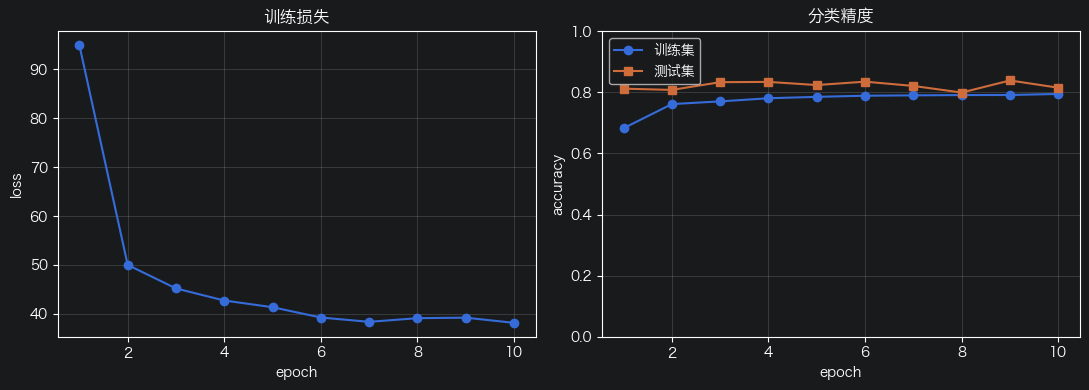

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().mean().item()

def evaluate_accuracy(net, data_iter):
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            correct += (net(X).argmax(dim=1) == y).sum().item()
            total += y.numel()
    net.train()
    return correct / total

num_epochs = 10
train_losses, train_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    total_loss, total_correct, total_n = 0.0, 0, 0
    for X, y in train_iter:
        trainer.zero_grad()
        y_hat = net(X)
        l = loss(y_hat, y).sum()
        l.backward()
        trainer.step()
        total_loss    += l.item()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total_n       += y.numel()
    train_loss = total_loss / total_n
    train_acc  = total_correct / total_n
    test_acc   = evaluate_accuracy(net, test_iter)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f'epoch {epoch+1:2d}  loss {train_loss:.4f}  '
          f'train acc {train_acc:.3f}  test acc {test_acc:.3f}')

# 绘制曲线
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, train_losses, marker='o')
axes[0].set_title('训练损失')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_accs, marker='o', label='训练集')
axes[1].plot(epochs, test_accs,  marker='s', label='测试集')
axes[1].set_title('分类精度')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()